In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from math import log2
from PIL import Image


In [2]:
DATASET_DIR = "dataset_split"
IMG_SIZE = 32


In [3]:
def extract_features(img_path):
    img = Image.open(img_path).convert("L")  # gri seviye
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img)

    return [
        arr.mean(),   # ortalama parlaklık
        arr.std(),    # kontrast
        arr.min(),    # minimum piksel
        arr.max()     # maksimum piksel
    ]


In [4]:
def load_data(split):
    rows = []
    split_path = os.path.join(DATASET_DIR, split)

    for label in os.listdir(split_path):
        class_path = os.path.join(split_path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            features = extract_features(img_path)
            rows.append(features + [label])

    return pd.DataFrame(
        rows,
        columns=["mean", "std", "min", "max", "label"]
    )


In [5]:
def entropy(labels):
    counts = Counter(labels)
    total = len(labels)
    return -sum((c/total)*log2(c/total) for c in counts.values())


In [6]:
def info_gain(df, feature):
    total_entropy = entropy(df["label"])
    threshold = df[feature].median()

    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]

    weighted_entropy = (
        len(left)/len(df)*entropy(left["label"]) +
        len(right)/len(df)*entropy(right["label"])
    )

    return total_entropy - weighted_entropy


In [7]:
def build_tree(df, depth=0, max_depth=3):
    if len(df["label"].unique()) == 1 or depth == max_depth:
        return df["label"].mode()[0]

    gains = {f: info_gain(df, f) for f in df.columns[:-1]}
    best_feature = max(gains, key=gains.get)
    threshold = df[best_feature].median()

    left = df[df[best_feature] <= threshold]
    right = df[df[best_feature] > threshold]

    return {
        "feature": best_feature,
        "threshold": threshold,
        "left": build_tree(left, depth+1),
        "right": build_tree(right, depth+1)
    }


In [8]:
def predict(tree, row):
    if isinstance(tree, str):
        return tree

    if row[tree["feature"]] <= tree["threshold"]:
        return predict(tree["left"], row)
    else:
        return predict(tree["right"], row)


In [9]:
train_df = load_data("train")
test_df = load_data("test")

tree = build_tree(train_df)

y_true = test_df["label"].values
y_pred = test_df.apply(lambda r: predict(tree, r), axis=1)

accuracy = np.mean(y_true == y_pred)
print("Decision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.23076923076923078


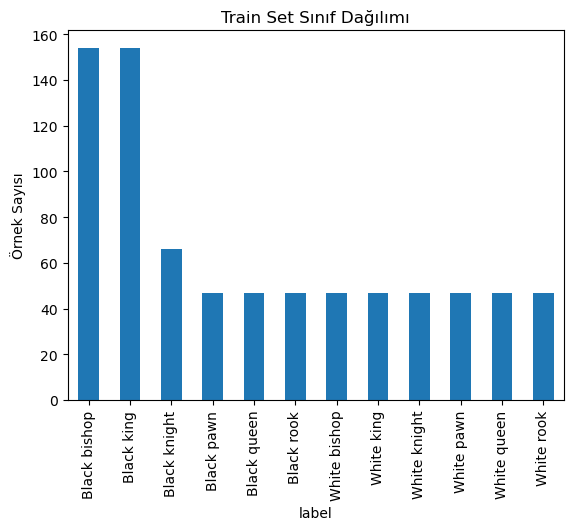

In [10]:
train_df["label"].value_counts().plot(kind="bar")
plt.title("Train Set Sınıf Dağılımı")
plt.ylabel("Örnek Sayısı")
plt.show()
